In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


from rf_computation import compute_final_rfs

dae_rfs = compute_final_rfs(model_type='sae-latent-pca-init-frozen-v2', dataset='cifar', size_ls=None, num_models=1, num_epochs=40, base_path=os.path.expanduser('~/'))

SAE-LATENT-PCA-INIT-FROZEN-V2:   0%|          | 0/1 [00:00<?, ?it/s]

/home/david/cifar_models/sae-latent-pca-init-frozen-v2/0/model_weights_epoch39.pth


SAE-LATENT-PCA-INIT-FROZEN-V2: 100%|██████████| 1/1 [00:26<00:00, 26.56s/it]


In [5]:
import numpy as np
np.array(dae_rfs).shape

(1, 128, 3, 32, 32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-115.80519..96.96685].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-149.7827..92.9397].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-130.27579..100.83227].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-147.35979..98.95091].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-120.681595..99.25645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-121.657486..103.01645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-124.36416..1

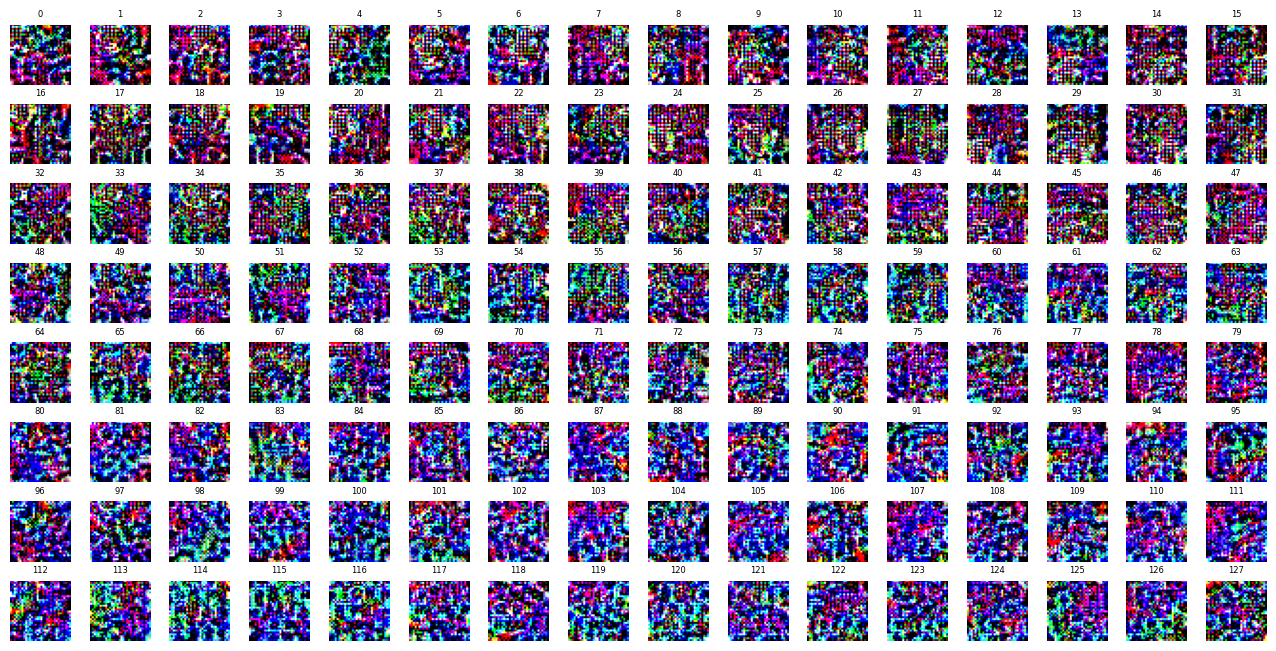

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Assume dae_rfs shape: (1, 128, 3, 32, 32)
rf_array = np.array(dae_rfs)
assert rf_array.shape[0] == 1 and rf_array.shape[1] == 128, f"Unexpected shape {rf_array.shape}"
imgs = rf_array[0]  # (128, 3, 32, 32)

# Normalize across all filters for consistent color scaling
vmin, vmax = imgs.min(), imgs.max()
rng = vmax - vmin if vmax > vmin else 1.0

n_filters = imgs.shape[0]
cols = 16
rows = int(np.ceil(n_filters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.8, rows * 0.8))
axes = axes.flatten()

for i in range(cols * rows):
    ax = axes[i]
    if i < n_filters:
        img = np.transpose(imgs[i], (1, 2, 0))  # (32,32,3)
        ax.imshow(img)
        ax.set_title(str(i), fontsize=6)
    ax.axis('off')

plt.tight_layout(pad=0.3)
plt.show()
#

In [ ]:
from power_spectra import analyze_power_spectra

analyze_power_spectra('cifar', 
                      'Results/cifar_sae-latent-pca-init-frozen_final_rfs.npy', 
                      'Results/cifar_dae_rfs.npy',
                      num_models=1,
                      epoch=49,
)

FileNotFoundError: [Errno 2] No such file or directory: 'Results/cifar_sae-latent-pca-init-frozen_final_rfs.npy'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-115.80519..96.96685].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-149.7827..92.9397].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-130.27579..100.83227].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-147.35979..98.95091].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-120.681595..99.25645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-121.657486..103.01645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-124.36416..1

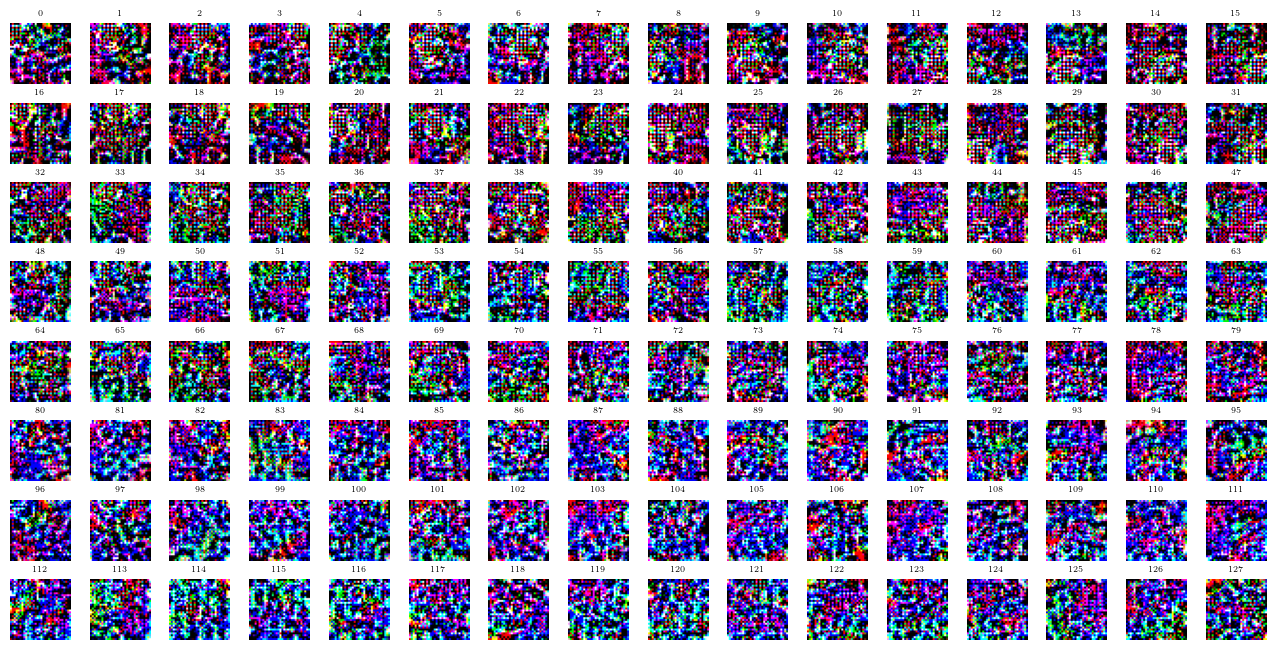

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Assume dae_rfs shape: (1, 128, 3, 32, 32)
rf_array = np.array(dae_rfs)
assert rf_array.shape[0] == 1 and rf_array.shape[1] == 128, f"Unexpected shape {rf_array.shape}"
imgs = rf_array[0]  # (128, 3, 32, 32)

# Normalize across all filters for consistent color scaling
vmin, vmax = imgs.min(), imgs.max()
rng = vmax - vmin if vmax > vmin else 1.0

n_filters = imgs.shape[0]
cols = 16
rows = int(np.ceil(n_filters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.8, rows * 0.8))
axes = axes.flatten()

for i in range(cols * rows):
    ax = axes[i]
    if i < n_filters:
        img = np.transpose(imgs[i], (1, 2, 0))  # (32,32,3)
        ax.imshow(img)
        ax.set_title(str(i), fontsize=6)
    ax.axis('off')

plt.tight_layout(pad=0.3)
plt.show()

In [8]:
dae_rfs = np.repeat(dae_rfs, 10, axis=0)
dae_rfs = np.repeat(dae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
print(dae_rfs.shape)
np.save('Results/cifar_sae-latent-pca-init-frozen_final_rfs.npy', dae_rfs)

(10, 60, 128, 3, 32, 32)


In [11]:
sae_rfs = np.load('Results/cifar_sae_rfs.npy')

In [13]:
from power_spectra import compute_power_spectra

sae_power_spectra, dae_power_spectra = compute_power_spectra(save_path_sae=None, save_path_dae=None, sae_rfs=sae_rfs, dae_rfs=dae_rfs, num_models=10, epoch=39)

100%|██████████| 10/10 [00:00<00:00, 21.68it/s]


In [14]:
from power_spectra import plot_power_spectra

plot_power_spectra(model_type='cifar', sae_power_spectra=sae_power_spectra, dae_power_spectra=dae_power_spectra)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
